# **1. 손 글씨 숫자 데이터셋**
손글씨 숫자 데이터셋은 0부터 9까지의 숫자를 손글씨로 쓴 흑백 이미지로 구성되어 있으며, 각 이미지는 8x8 픽셀 크기의 64차원 벡터로 표현됩니다. 각 픽셀 값은 0(흰색)에서 16(검은색)까지의 명암값을 가집니다. 이 데이터는 총 1797개의 샘플로 이루어져 있으며, 각 샘플에는 숫자 클래스(0~9)가 레이블로 붙어 있습니다. 주로 분류 알고리즘을 학습시키거나 데이터 시각화, 차원 축소 기법 등을 실험하는 데 사용됩니다.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

In [2]:
digits = load_digits()

In [4]:
X_data = digits['data']
y_data = digits['target']
print(X_data.shape)
print(y_data.shape)

(1797, 64)
(1797,)


### ※ axes.flatten()

axes.flatten()은 다차원 배열 형태로 구성된 Matplotlib의 서브플롯 배열을 1차원 배열로 변환하는 메서드입니다. Matplotlib에서 다수의 서브플롯을 생성할 때, plt.subplots()는 2차원 배열 형태로 서브플롯 객체를 반환합니다. 이 배열은 각 서브플롯을 접근하기 위해 행과 열의 인덱스를 사용해야 하지만, flatten() 메서드를 사용하면 이 배열을 1차원으로 펼쳐서 각 서브플롯을 단일 인덱스로 순회할 수 있게 됩니다.

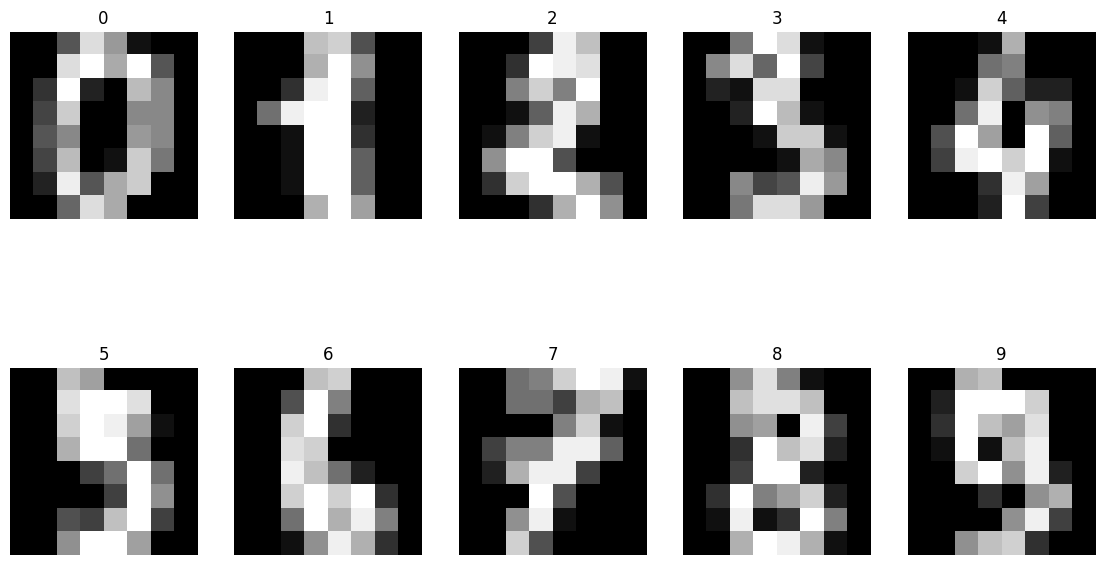

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(14, 8))

for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_data[i].reshape((8, 8)), cmap='gray')
    ax.set_title(y_data[i])
    ax.axis('off')

In [8]:
X_data = torch.FloatTensor(X_data)
y_data = torch.LongTensor(y_data)
print(X_data.shape)
print(y_data.shape)

torch.Size([1797, 64])
torch.Size([1797])


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([360, 64]) torch.Size([360])


# **2. 데이터 로더**
데이터로더(Data Loader)는 데이터셋을 효율적으로 관리하고, 모델 학습 과정에서 데이터를 쉽게 가져올 수 있도록 도와주는 도구입니다. 일반적으로 데이터셋을 배치(batch) 단위로 나누어 모델에 제공하며, 데이터의 크기가 클 경우에도 메모리 효율적으로 처리할 수 있도록 설계되었습니다. 데이터 증강, 셔플링, 병렬 처리와 같은 기능을 지원하여 학습 성능을 향상시키고, 모델 학습과 평가 시 일관된 데이터 제공 방식을 유지합니다. 딥러닝 프레임워크에서는 PyTorch의 DataLoader나 TensorFlow의 tf.data 같은 도구를 통해 쉽게 사용할 수 있습니다.

### ※ 데이터로더의 주요 역할

1. 배치 처리: 데이터를 지정된 크기의 배치로 나누어 모델에 제공.
2. 셔플링: 데이터 순서를 무작위로 섞어 과적합 방지.
3. 병렬 처리: num_workers 옵션을 통해 데이터를 병렬로 로드하여 속도 향상.
4. 반복 처리: 학습 epoch 동안 데이터를 자동으로 반복해서 제공.

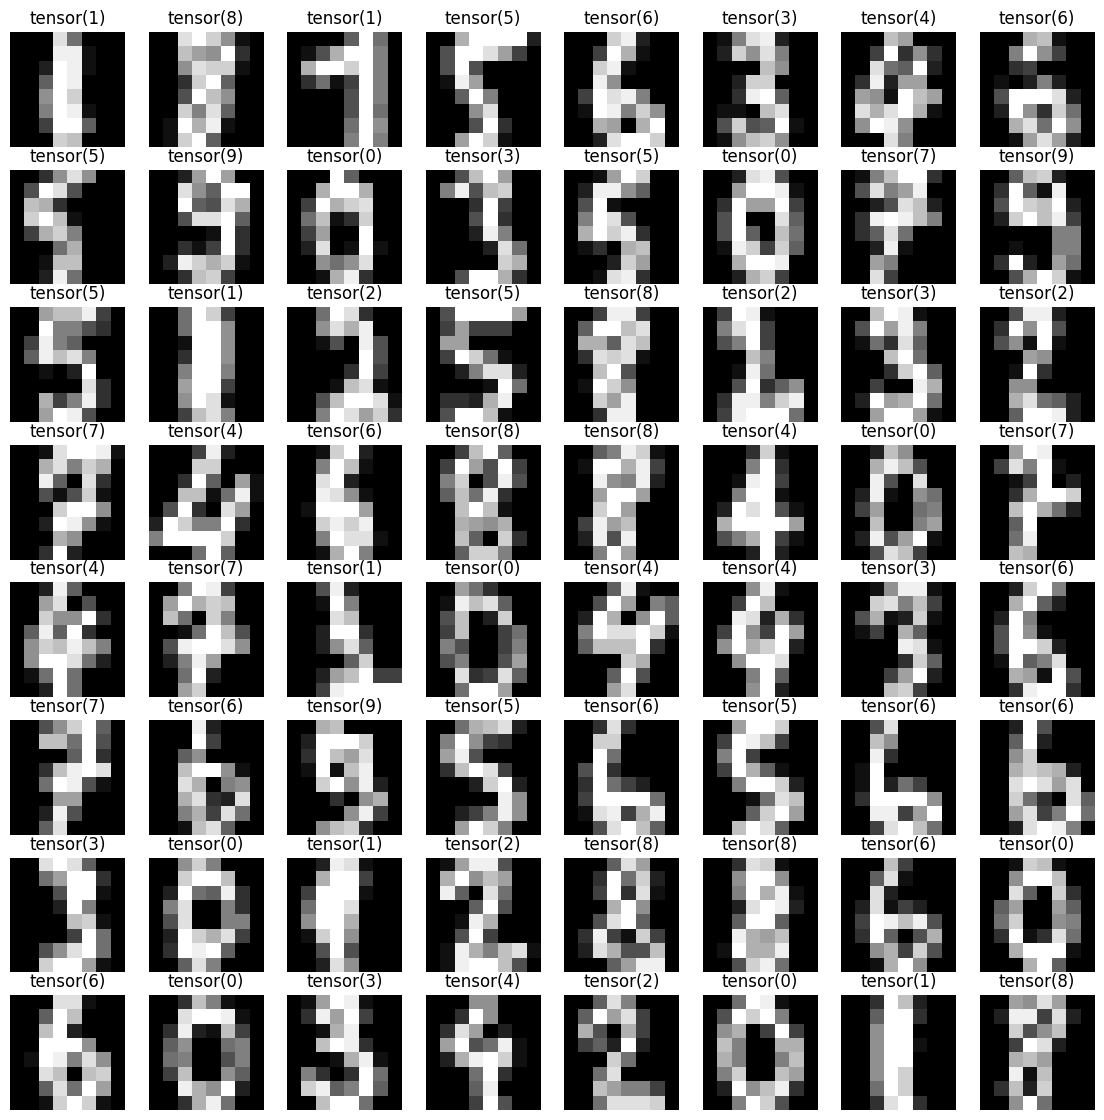

In [10]:
loader = DataLoader(
    dataset=list(zip(X_train, y_train)),
    batch_size=64,
    shuffle = True,
    drop_last=False
)

imgs, labels = next(iter(loader))
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')

In [11]:
model = nn.Sequential(
    nn.Linear(64, 10)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50

for epoch in range(epochs + 1):
    sum_losses = 0
    sum_accs = 0

    for x_batch, y_batch in loader:
        y_pred = model(x_batch)
        loss = nn.CrossEntropyLoss()(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_losses = sum_losses + loss

        y_prob = nn.Softmax(1)(y_pred)
        y_pred_index = torch.argmax(y_prob, axis=1)
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100
        sum_accs = sum_accs + acc

    avg_loss = sum_losses / len(loader)
    avg_acc = sum_accs / len(loader)
    print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.656565 Accuracy: 60.38%
Epoch    1/50 Loss: 0.224624 Accuracy: 92.38%
Epoch    2/50 Loss: 0.142465 Accuracy: 95.92%
Epoch    3/50 Loss: 0.129252 Accuracy: 95.98%
Epoch    4/50 Loss: 0.109407 Accuracy: 97.21%
Epoch    5/50 Loss: 0.091504 Accuracy: 97.81%
Epoch    6/50 Loss: 0.082541 Accuracy: 97.13%
Epoch    7/50 Loss: 0.076470 Accuracy: 97.99%
Epoch    8/50 Loss: 0.077258 Accuracy: 97.35%
Epoch    9/50 Loss: 0.062834 Accuracy: 98.17%
Epoch   10/50 Loss: 0.049831 Accuracy: 98.70%
Epoch   11/50 Loss: 0.048036 Accuracy: 98.64%
Epoch   12/50 Loss: 0.049559 Accuracy: 98.78%
Epoch   13/50 Loss: 0.039941 Accuracy: 99.12%
Epoch   14/50 Loss: 0.033972 Accuracy: 99.39%
Epoch   15/50 Loss: 0.033414 Accuracy: 99.39%
Epoch   16/50 Loss: 0.026619 Accuracy: 99.39%
Epoch   17/50 Loss: 0.028883 Accuracy: 99.46%
Epoch   18/50 Loss: 0.025698 Accuracy: 99.25%
Epoch   19/50 Loss: 0.023754 Accuracy: 99.73%
Epoch   20/50 Loss: 0.022520 Accuracy: 99.59%
Epoch   21/50 Loss: 0.024239 Accur

tensor(7)


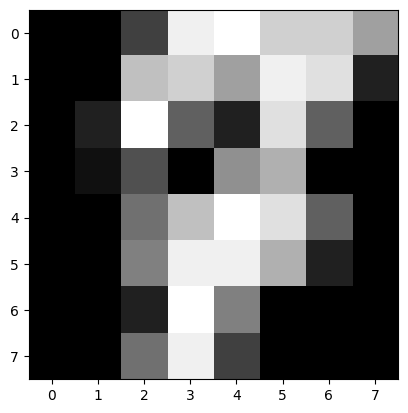

In [13]:
plt.imshow(X_test[15].reshape((8, 8)), cmap='gray')
print(y_test[15])

In [14]:
y_pred = model(X_test)
y_pred[15]

tensor([ -6.2708,  -4.3502, -10.5345,   0.6848,   3.5809,   3.9968,  -8.1190,
         19.8975,  -5.7381,  -5.3221], grad_fn=<SelectBackward0>)

In [15]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[15]

tensor([4.3178e-12, 2.9468e-11, 6.0749e-14, 4.5293e-09, 8.1990e-08, 1.2428e-07,
        6.8008e-13, 1.0000e+00, 7.3554e-12, 1.1149e-11],
       grad_fn=<SelectBackward0>)

In [16]:
for i in range(10):
    print(f'숫자 {i}일 확률: {y_prob[15][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.00
숫자 3일 확률: 0.00
숫자 4일 확률: 0.00
숫자 5일 확률: 0.00
숫자 6일 확률: 0.00
숫자 7일 확률: 1.00
숫자 8일 확률: 0.00
숫자 9일 확률: 0.00


In [17]:
y_pred_index = torch.argmax(y_prob, axis=1)
accuracy = (y_test == y_pred_index).float().sum() / len(y_test) * 100
print(f'테스트 정확도는 {accuracy: .2f}% 입니다')

테스트 정확도는  95.28% 입니다


# **3. 데이터 증강**
데이터 증강(Data Augmentation)은 학습 데이터를 인위적으로 변환하여 데이터셋의 다양성을 높이고 모델의 일반화 성능을 향상시키는 기법입니다. 회전, 크기 조정, 반전, 블러링, 밝기 조정 등 다양한 변환을 적용하여 원본 데이터로부터 새로운 데이터를 생성합니다. 이를 통해 데이터 부족 문제를 완화하고 모델이 특정 패턴에 과적합되지 않도록 도와줍니다. 특히, 이미지나 음성 데이터와 같이 특징이 직관적인 데이터에서 효과적으로 활용되며, 증강된 데이터는 모델이 예측 대상의 다양한 변형에 대해 강하게 학습할 수 있도록 돕습니다.

In [18]:
from torchvision import transforms
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=2026)
print(X_train.shape, y_train.shape)
print(X_train.shape, y_test.shape)

torch.Size([1437, 64]) torch.Size([1437])
torch.Size([1437, 64]) torch.Size([360])


In [23]:
train_dataset = TensorDataset(X_train, y_train)
print(len(train_dataset))
print(train_dataset[0])
print(train_dataset[1])
print(train_dataset[2])

1437
(tensor([ 0.,  0.,  5., 11., 16., 16.,  5.,  0.,  0.,  3., 15., 11., 10., 16.,
         4.,  0.,  0.,  0.,  4.,  0., 10., 14.,  0.,  0.,  0.,  0.,  7., 15.,
        16., 16., 12.,  0.,  0.,  0.,  9., 16., 14.,  4.,  1.,  0.,  0.,  0.,
         1., 14.,  7.,  0.,  0.,  0.,  0.,  0.,  4., 16.,  4.,  0.,  0.,  0.,
         0.,  0.,  8., 16.,  0.,  0.,  0.,  0.]), tensor(7))
(tensor([ 0.,  3., 13., 16., 13.,  0.,  0.,  0.,  0.,  9., 13.,  8., 16.,  5.,
         1.,  0.,  0.,  0.,  8., 14., 16., 16.,  5.,  0.,  0.,  0.,  8., 16.,
        15.,  2.,  0.,  0.,  0.,  0.,  2., 16.,  7.,  0.,  0.,  0.,  0.,  0.,
         7., 16.,  4.,  0.,  0.,  0.,  0.,  0., 15.,  9.,  0.,  0.,  0.,  0.,
         0.,  2., 15.,  3.,  0.,  0.,  0.,  0.]), tensor(7))
(tensor([ 0.,  0.,  2., 13.,  6.,  0.,  0.,  0.,  0.,  0.,  4., 16., 15.,  5.,
         0.,  0.,  0.,  0.,  1., 15., 12., 15.,  0.,  0.,  0.,  0.,  0., 10.,
        16., 16.,  1.,  0.,  0.,  0.,  0.,  0.,  2., 16.,  2.,  0.,  0.,  0.,
         0.,

In [24]:
test_dataset = TensorDataset(X_test, y_test)

### ※ transforms.Compose

여러 데이터 변환(transform) 작업을 순차적으로 적용할 수 있도록 해줍니다. 이미지 데이터 전처리와 증강 과정에서 자주 사용되며, 각 변환을 하나의 리스트로 묶어 실행합니다.

1. transforms.RandomRotation(10)
    - 기능: 이미지를 -10도에서 +10도 사이로 무작위 회전시킵니다. 10은 회전 범위를 나타냅니다.
    - 각 호출 시, -10도 ~ +10도 범위에서 무작위로 각도를 선택하여 이미지를 회전합니다.
2. transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1))
    - 기능: 이미지를 비틀기(shear), 크기 조정(scale) 등의 변환을 수행합니다.
    - 0: 회전(각도) 변환을 수행하지 않음을 의미합니다.
    - shear=5: 이미지를 최대 5도만큼 비스듬하게 비틀기(shear) 변환을 수행합니다.
    - 예: 정사각형이 평행사변형처럼 기울어질 수 있습니다.
    - scale=(0.9, 1.1):
    - 이미지를 0.9배(축소)에서 1.1배(확대) 범위 내에서 무작위 크기 조정을 수행합니다.
    - 각 호출 시, 무작위로 크기가 변경됩니다.

In [26]:
transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(0, shear=5, scale=(0.9, 1.1))
])

In [27]:
class AugmentedDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        x = x.view(8, 8).unsqueeze(0)
        x = self.transform(x)
        return x.flatten(), y

In [28]:
augmentedDataset = AugmentedDataset(train_dataset, transform)

In [29]:
len(augmentedDataset)

1437

In [30]:
augmentedDataset[0]

(tensor([ 0.,  0.,  5., 11., 16., 16.,  5.,  0.,  0.,  3., 15., 11., 10., 16.,
          4.,  0.,  0.,  0.,  4.,  0., 10., 14.,  0.,  0.,  0.,  0.,  7., 15.,
         16., 16., 12.,  0.,  0.,  0.,  9., 16., 14.,  4.,  1.,  0.,  0.,  0.,
          1., 14.,  7.,  0.,  0.,  0.,  0.,  0.,  4., 16.,  4.,  0.,  0.,  0.,
          0.,  0.,  8., 16.,  0.,  0.,  0.,  0.]),
 tensor(7))

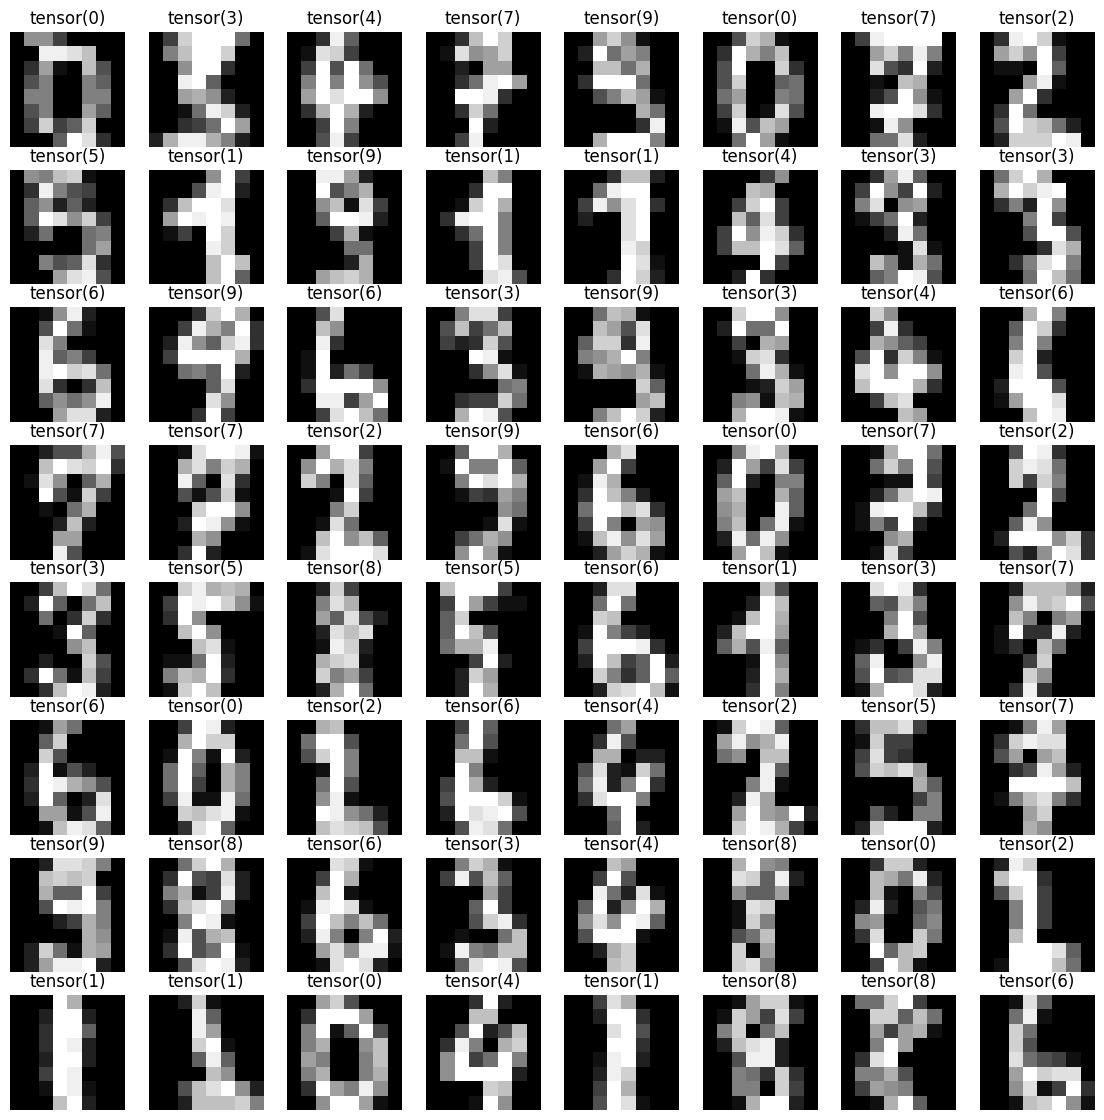

In [31]:
train_loader = DataLoader(augmentedDataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(nrows=8, ncols=8, figsize=(14, 14))

for ax, img, label in zip(axes.flatten(), imgs, labels):
    ax.imshow(img.reshape((8, 8)), cmap='gray')
    ax.set_title(str(label))
    ax.axis('off')

In [32]:
for images, labels in train_loader:
    print(f"Image batch shape: {images.shape}")
    print(f"Label batch shape: {labels.shape}")
    break

Image batch shape: torch.Size([64, 64])
Label batch shape: torch.Size([64])


In [33]:
model = nn.Sequential(
    nn.Linear(64, 10)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50
for epoch in range(epochs + 1):
    sum_losses = 0
    sum_accs = 0

    for x_batch, y_batch in train_loader:
        y_pred = model(x_batch)
        loss = nn.CrossEntropyLoss()(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        sum_losses = sum_losses + loss

        y_prob = nn.Softmax(1)(y_pred)
        y_pred_index = torch.argmax(y_prob, axis=1)
        acc = (y_batch == y_pred_index).float().sum() / len(y_batch) * 100
        sum_accs = sum_accs + acc

    if epoch % 10 == 0:
        avg_loss = sum_losses / len(loader)
        avg_acc = sum_accs / len(loader)
        print(f'Epoch {epoch:4d}/{epochs} Loss: {avg_loss:.6f} Accuracy: {avg_acc:.2f}%')

Epoch    0/50 Loss: 1.695828 Accuracy: 58.20%
Epoch   10/50 Loss: 0.087562 Accuracy: 96.79%
Epoch   20/50 Loss: 0.035850 Accuracy: 99.12%
Epoch   30/50 Loss: 0.030488 Accuracy: 99.24%
Epoch   40/50 Loss: 0.038207 Accuracy: 98.85%
Epoch   50/50 Loss: 0.023285 Accuracy: 99.51%


tensor(5)


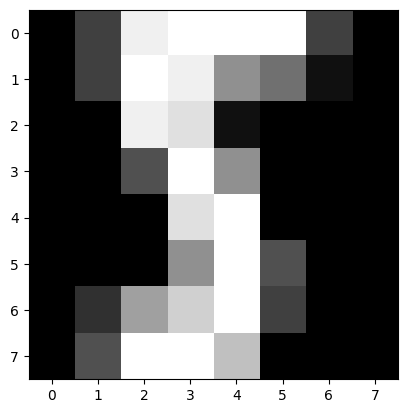

In [34]:
plt.imshow(X_test[11].reshape((8, 8)), cmap='gray')
print(y_test[11])

In [36]:
y_pred = model(X_test)
y_pred[11]

tensor([ -9.7139,  -4.9779,  -1.4954,   5.6122, -13.0109,  16.1444, -11.9327,
         -4.7813,   6.6647,   1.5557], grad_fn=<SelectBackward0>)

In [37]:
y_prob = nn.Softmax(1)(y_pred)
y_prob[11]

tensor([5.8858e-12, 6.7085e-10, 2.1831e-08, 2.6661e-05, 2.1774e-13, 9.9990e-01,
        6.4001e-13, 8.1665e-10, 7.6374e-05, 4.6146e-07],
       grad_fn=<SelectBackward0>)

In [38]:
for i in range(10):
    print(f'숫자 {i}일 확률: {y_prob[11][i]:.2f}')

숫자 0일 확률: 0.00
숫자 1일 확률: 0.00
숫자 2일 확률: 0.00
숫자 3일 확률: 0.00
숫자 4일 확률: 0.00
숫자 5일 확률: 1.00
숫자 6일 확률: 0.00
숫자 7일 확률: 0.00
숫자 8일 확률: 0.00
숫자 9일 확률: 0.00
